# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [1]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

C:\Users\luisg\anaconda3\envs\transit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [2]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

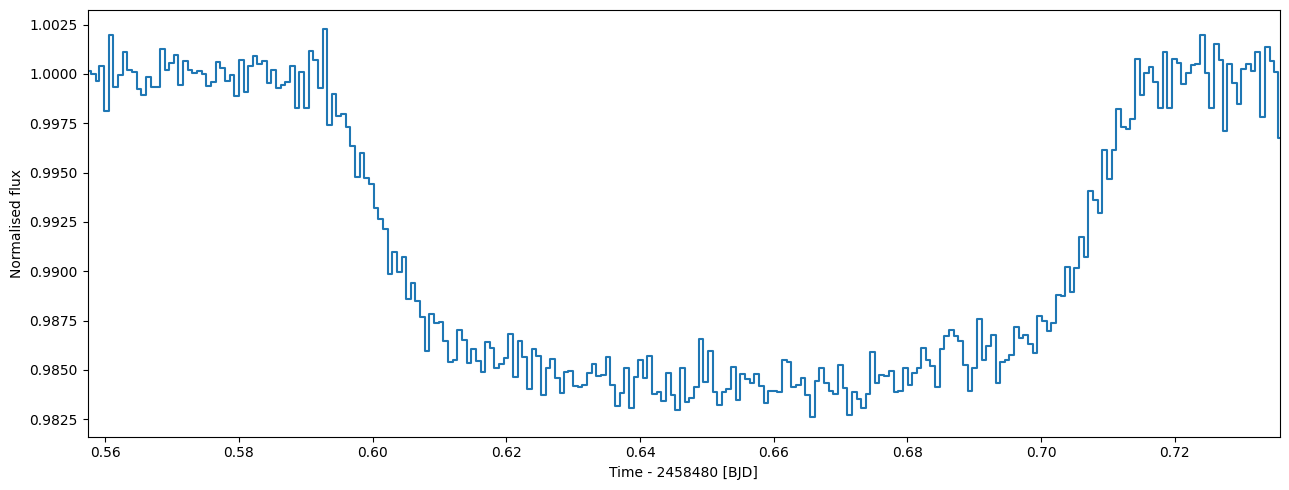

In [3]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [4]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [5]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [6]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

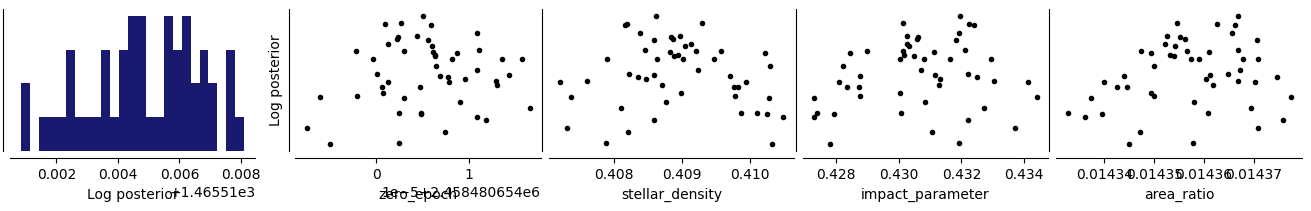

In [7]:
lpf.optimize_global(niter=500, npop=50)

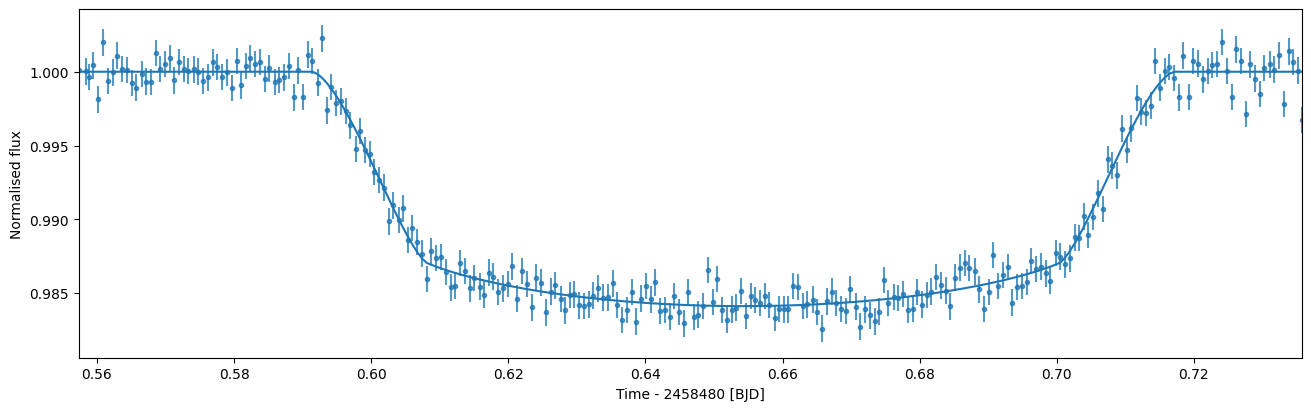

In [8]:
lpf.plot_light_curve();

In [9]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling: 100%|██████████| 2/2 [01:07<00:00, 33.61s/it] 


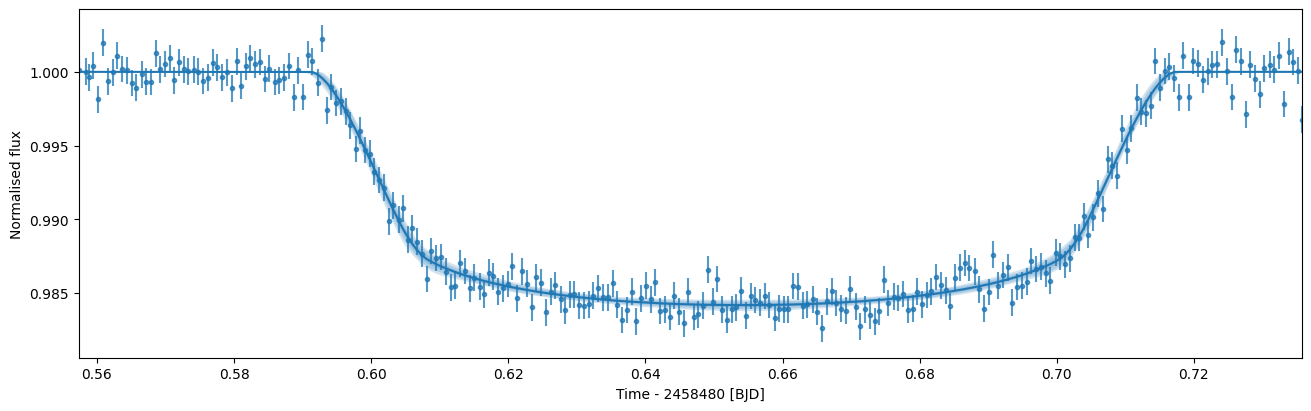

In [10]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

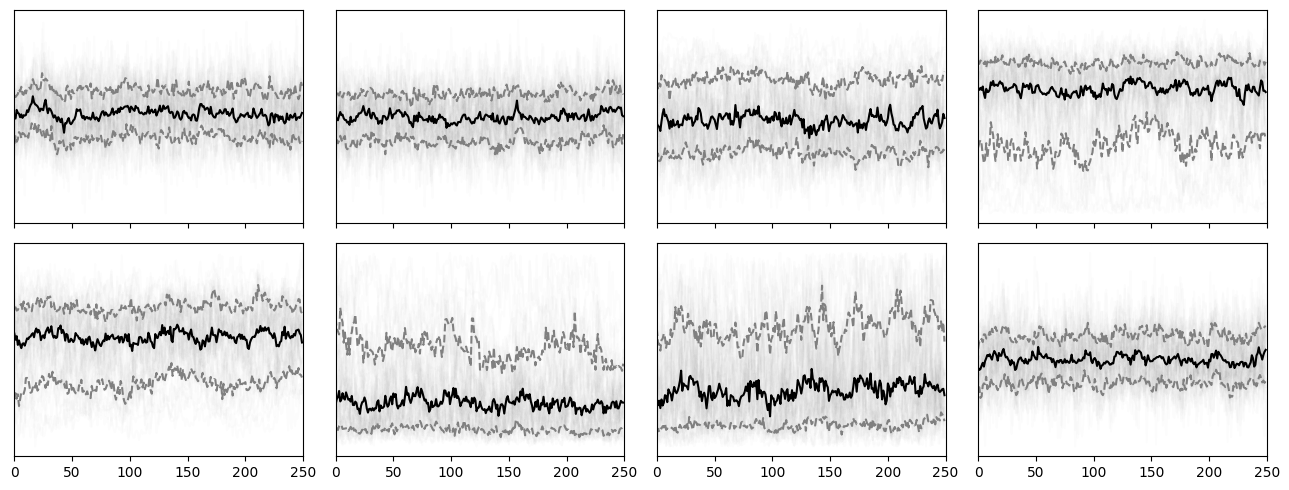

In [11]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [12]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [13]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

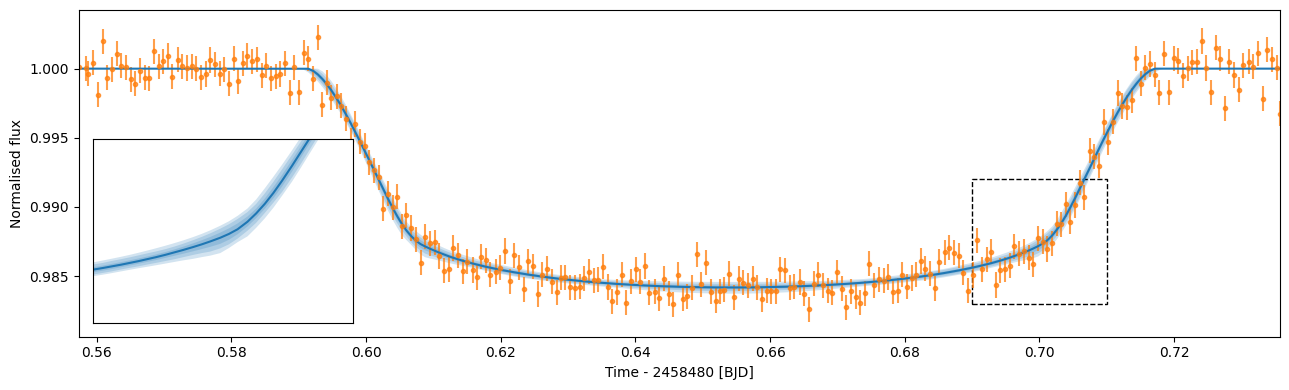

In [14]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [15]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4335,3.3678e-01,0.0140,0.3230,0.3482,-3.0412,0.1181,3.0087,1.4574,0.1258,0.0946
std,1.5948e-04,1.1035e-09,0.0367,1.2560e-01,0.0005,0.2108,0.2440,0.0191,0.0020,0.0850,0.0444,0.0010,0.0027
min,2.4585e+06,1.0914e+00,0.3334,8.6257e-05,0.0126,0.0485,0.0003,-3.1079,0.1124,2.7587,1.3602,0.1225,0.0860
25%,2.4585e+06,1.0914e+00,0.4059,2.7040e-01,0.0136,0.1583,0.1493,-3.0543,0.1167,2.9456,1.4243,0.1252,0.0926
50%,2.4585e+06,1.0914e+00,0.4309,3.7051e-01,0.0140,0.2621,0.2894,-3.0415,0.1185,3.0049,1.4471,0.1258,0.0943
75%,2.4585e+06,1.0914e+00,0.4616,4.2979e-01,0.0143,0.4338,0.5074,-3.0284,0.1197,3.0746,1.4827,0.1265,0.0966
max,2.4585e+06,1.0914e+00,0.5361,5.7679e-01,0.0151,0.9996,0.9994,-2.9599,0.1229,3.2319,1.5708,0.1298,0.1011


<Axes: >

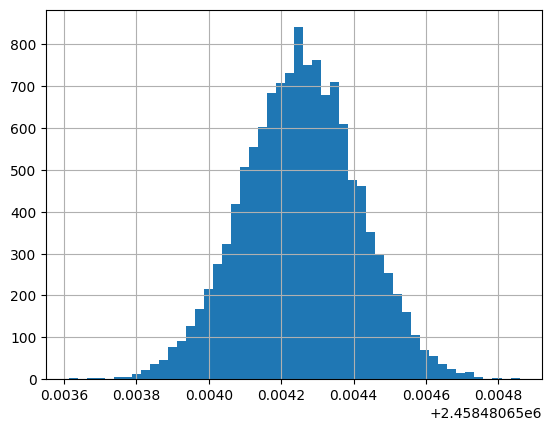

In [16]:
df.tc.hist(bins=50)

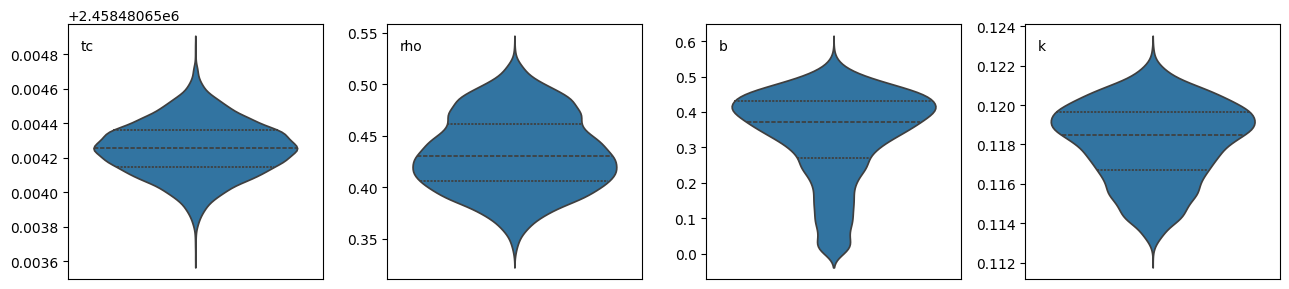

In [17]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

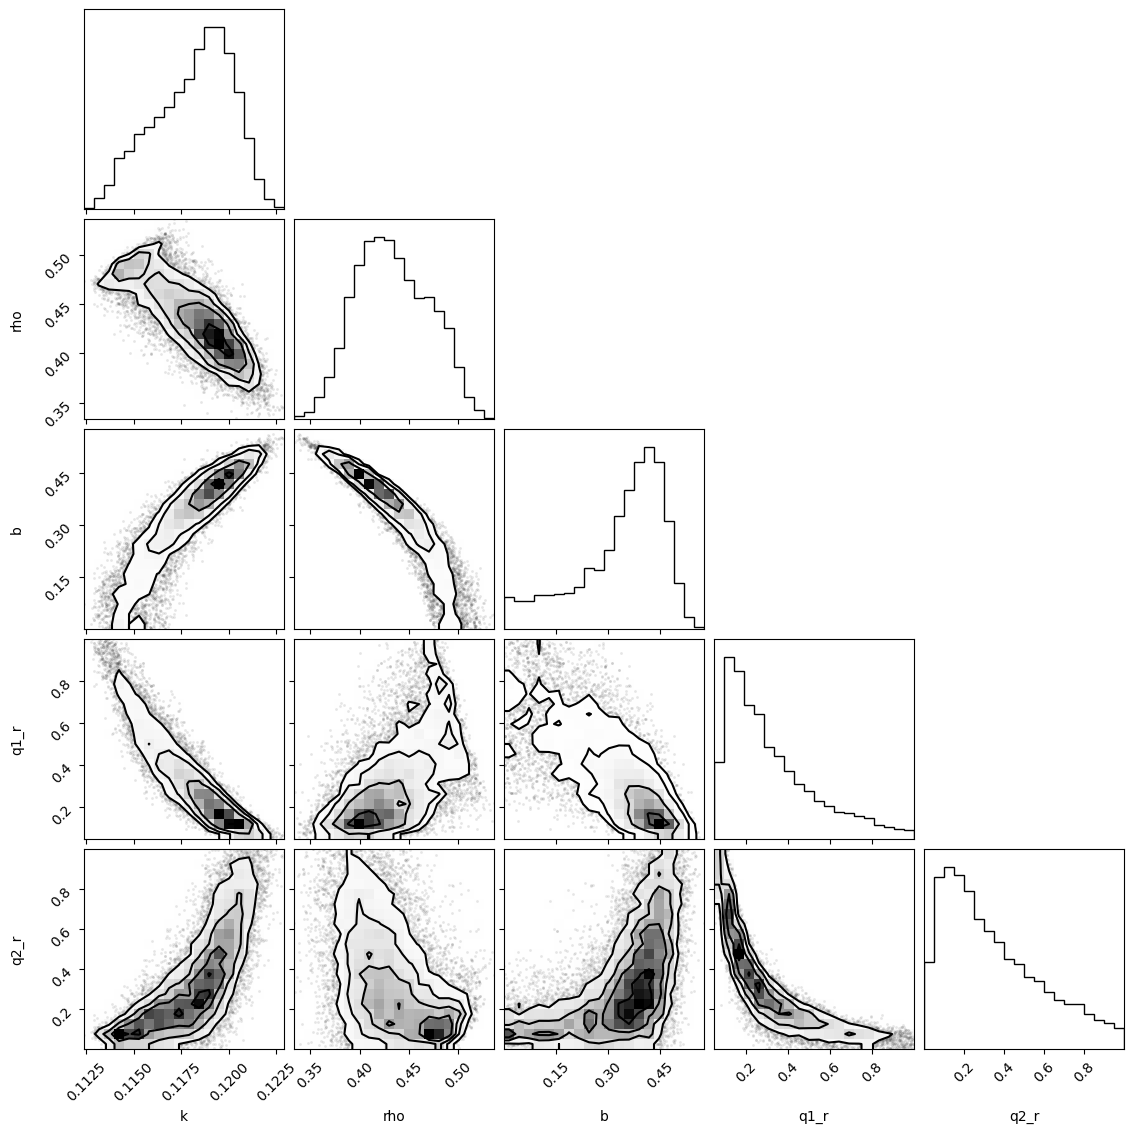

In [18]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

$R_p  = 1.810^{+0.026}_{-0.041} \, R_J$


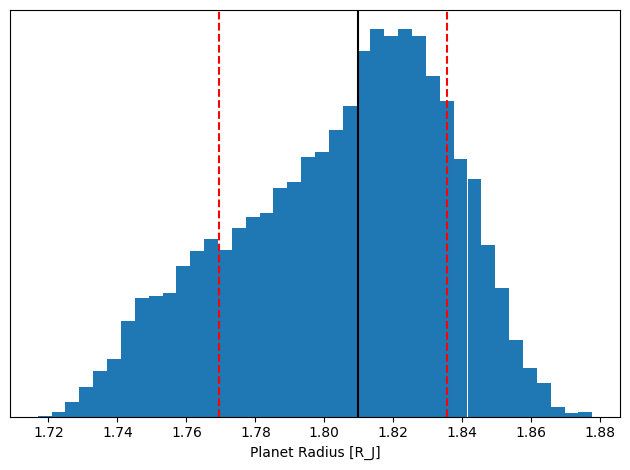

In [19]:
import astropy.units as u
import numpy as np

Rstar=1.57*u.Rsun
k=df.k.to_numpy()

Rp=k*Rstar
RpJ=Rp.to(u.Rjup)

R=RpJ.value
medianR=np.median(R)
R1,R2=np.percentile(R,[16, 84])
e1=medianR-R1
e2=R2-medianR
print(f"$R_p  = {medianR:.3f}"f"^{{+{e2:.3f}}}_{{-{e1:.3f}}} \\, R_J$")


fig, ax = subplots()
ax.hist(R, bins=40)
ax.axvline(median(R), c='k')
ax.axvline(R1, c='r', linestyle='--')
ax.axvline(R2, c='r', linestyle='--')
setp(ax, xlabel='Planet Radius [R_J]', yticks=[])
fig.tight_layout()

$$R_p = 1.810^{+0.026}_{-0.041} \, R_\mathrm{J}$$

2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

ho_p  = 0.285^{+0.020}_{-0.012} \, g/cm^3$


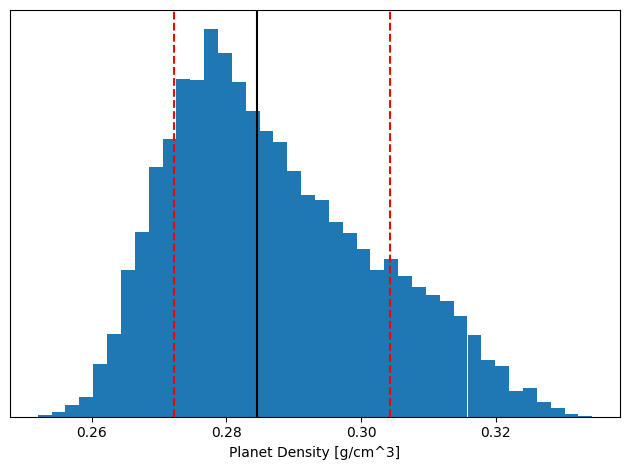

In [20]:
Mp=np.load("mpsin_samples.npy")*u.Mjup

n=min(len(Mp),len(RpJ))
Mp1=Mp[np.random.choice(len(Mp),n,replace=False)]
RpJ1=RpJ[np.random.choice(len(RpJ),n,replace=False)]

rho=3*Mp1/(4*np.pi*RpJ1**3)
rho=rho.to(u.g/u.cm**3)

rhop=rho.value
medianrho=np.median(rhop)
rho1,rho2=np.percentile(rhop,[16, 84])
e1=medianrho-rho1
e2=rho2-medianrho
print(f"$\rho_p  = {medianrho:.3f}"f"^{{+{e2:.3f}}}_{{-{e1:.3f}}} \\, g/cm^3$")


fig, ax = subplots()
ax.hist(rhop, bins=40)
ax.axvline(median(rhop), c='k')
ax.axvline(rho1, c='r', linestyle='--')
ax.axvline(rho2, c='r', linestyle='--')
setp(ax, xlabel='Planet Density [g/cm^3]', yticks=[])
fig.tight_layout()

$$\rho_p=0.285^{+0.020}_{-0.012} \, \mathrm{{g/cm^{{3}}}}$$

3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

- Answer: The radial velocity method provides a lower bound on the planet’s mass due to the sine term that multiplies the planet’s mass. This sine factor, which depends on the orbital inclination, is unknown in the radial velocity method. However, in the transit method, we know that the planet passes in front of the star, so that $\sin i \approx 1$. In this way, the minimum mass estimated from the radial velocity method becomes an approximate value of the true planetary mass.
  A better way to estimate planetary properties would be through a joint model in which the two previous approaches are not treated separately. That is, by simultaneously fitting the transit light curve (photometry) and the radial velocity (RV) curve. This single, physically consistent model would properly propagate uncertainties, avoid inconsistencies, and improve precision, among other advantages.
  
   
4. What can you say about WASP-12b as a planet based on its orbirtal period, radius, mass, and bulk density?

- Answer: We can again confirm that it is a hot Jupiter, as it orbits much closer to its host star than Mercury does to the Sun, has a radius nearly twice that of Jupiter, and a similar mass. Regarding its density, it is lower than Jupiter’s due to the reasons described previously (larger size but similar mass).

5. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.

- Answer: After the exercises, we present the histogram of the estimated stellar density. We obtain:
  $$\rho_\star=0.431^{+0.044}_{-0.035} \, \mathrm{{g/cm^{{3}}}}$$
  Knowing that the star has a mass of 1.35 solar masses and a radius of 1.57 solar radii, we obtain a theoretical density of:
  $$\rho^{th}_\star=0.49 \, \mathrm{{g/cm^{{3}}}}$$
  We see that the theoretical value is quite close to the one obtained from the fit.

6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

- Answer: If they are correlated, it means that they are not independent of each other in the fit. In practice, this means that the model exhibits degeneracies, that different combinations of parameters can explain the data in a similar way, and also that the posterior distributions cannot be interpreted separately. As a result, we should not interpret the parameters in isolation.


ho_star  = 0.431^{+0.044}_{-0.035} \, g/cm^3$


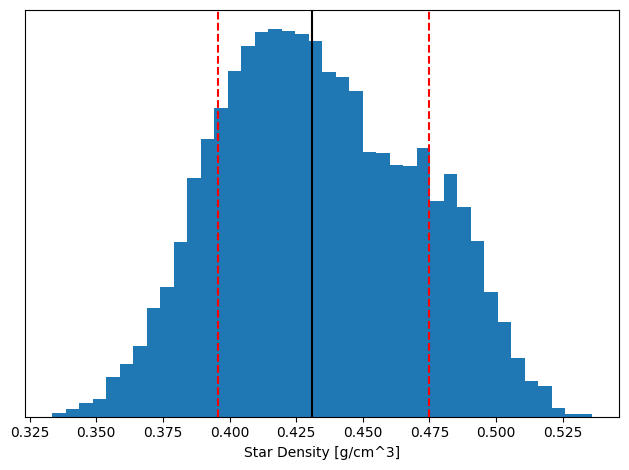

In [21]:
medianrhostar=np.median(df.rho)
rhostar1,rhostar2=np.percentile(df.rho,[16, 84])
e1=medianrhostar-rhostar1
e2=rhostar2-medianrhostar
print(f"$\rho_star  = {medianrhostar:.3f}"f"^{{+{e2:.3f}}}_{{-{e1:.3f}}} \\, g/cm^3$")

fig, ax = subplots()
ax.hist(df.rho, bins=40)
ax.axvline(median(df.rho), c='k')
ax.axvline(rhostar1, c='r', linestyle='--')
ax.axvline(rhostar2, c='r', linestyle='--')
setp(ax, xlabel='Star Density [g/cm^3]', yticks=[])
fig.tight_layout()

---
<center>&copy;2026 Hannu Parviainen</center>